# EDA: Incorrect Economizer Setpoint (Experimental Dataset)

## Fault details (per LBNL documentation)

The economizer is enabled when OA temperature is below its setpoint (documented
correct value: 10°C / 50°F) AND mixed air temperature is above 45°F. This fault
modifies the setpoint itself in the control programming — not a physical position
like OA damper stuck, but a logic/calibration error.

Four severities, given in the documentation as actual setpoint values: 6°C, 8°C, 12°C,
14°C — representing -4°C, -2°C, +2°C, +4°C deviations from the correct 10°C.

## Design decision, carried over from notebook 08

Within-season comparison, per notebook 07's finding that pooling across seasons is
unsafe. Starting with Winter_2022 again, for consistency with notebook 08 and because
Winter's baseline already showed the economizer genuinely active — the right
condition to test whether a wrong setpoint changes *when* the economizer engages.

## Hypothesis (before looking at any data)

- A setpoint that's too low (6°C, 8°C) should make the economizer harder to enable
  than correct (since OA temp needs to drop further below a lower threshold) —
  expect `RTU_OA_DMPR_DM` to sit lower/more restricted than baseline for these two.
- A setpoint that's too high (12°C, 14°C) should make the economizer easier to enable
  — expect `RTU_OA_DMPR_DM` to sit higher/more open than baseline for these two.
- Real, falsifiable question carried from notebook 08: does `RTU_SA_TEMP` again stay
  flat (masked by compensation), or does this fault behave differently since it's a
  logic error rather than a forced physical position?
- Unlike OA damper stuck (where the fault is a fixed number, directly comparable to
  the signal that reveals it), this fault's effect depends on that day's actual
  outdoor temperature relative to each wrong setpoint — a -4°C setpoint only matters
  if OA temp is actually near the boundary; if OA temp is very cold or very warm all
  day, a wrong setpoint by a few degrees may not change economizer behavior at all.
  Worth checking each file's OA_TEMP range, not just its mean, before interpreting
  results.

In [1]:
import pandas as pd

files = {
    "baseline": "../data/raw/experimental/ERTU_Winter_2022.csv",
    "econ_06": "../data/raw/experimental/Inc_Eco_SP_-4_Winter_2022.csv",
    "econ_08": "../data/raw/experimental/Inc_Eco_SP_-2_Winter_2022.csv",
    "econ_12": "../data/raw/experimental/Inc_Eco_SP_2_Winter_2022.csv",
    "econ_14": "../data/raw/experimental/Inc_Eco_SP_4_Winter_2022.csv",
}

dfs = {label: pd.read_csv(fname, na_values=["NAN"]) for label, fname in files.items()}

for _label, df in dfs.items():
    df["Datetime"] = pd.to_datetime(df["Datetime"])

for _label, df in dfs.items():
    print(f"{_label}: shape={df.shape}, missing_values={df.isna().sum().sum()}")

print()
for _label, df in dfs.items():
    oa = df["RTU_OA_TEMP"]
    print(f"{_label}: OA_TEMP min={oa.min():.1f}, max={oa.max():.1f}, mean={oa.mean():.1f}")

baseline: shape=(2880, 57), missing_values=12155
econ_06: shape=(1440, 57), missing_values=6123
econ_08: shape=(1440, 57), missing_values=6656
econ_12: shape=(1440, 57), missing_values=6994
econ_14: shape=(1440, 57), missing_values=6734

baseline: OA_TEMP min=41.1, max=56.2, mean=48.6
econ_06: OA_TEMP min=0.0, max=56.0, mean=47.4
econ_08: OA_TEMP min=43.5, max=70.0, mean=61.1
econ_12: OA_TEMP min=49.0, max=76.5, mean=63.7
econ_14: OA_TEMP min=54.9, max=77.3, mean=67.3


## Critical finding before any fault comparison: OA_TEMP ranges differ dramatically
## across these five files — not just noise, a real confound requiring a different
## analysis approach

| File | OA_TEMP min | max | mean |
|---|---|---|---|
| baseline | 41.1°F | 56.2°F | 48.6°F |
| econ_06 (-4°C dev) | **0.0°F** | 56.0°F | 47.4°F |
| econ_08 (-2°C dev) | 43.5°F | 70.0°F | 61.1°F |
| econ_12 (+2°C dev) | 49.0°F | 76.5°F | 63.7°F |
| econ_14 (+4°C dev) | 54.9°F | 77.3°F | 67.3°F |

Only `econ_06` overlaps meaningfully with baseline's range. `econ_08`/`econ_12`/`econ_14`
were recorded on substantially warmer days (means 61-67°F vs. baseline's 48.6°F) — a
confound far larger than notebook 08's OA_TEMP variation (which only affected the mean
by a few degrees across files). **A simple mean-based comparison across these five
files would conflate the setpoint fault with a large, uncontrolled weather difference**
— not safe to interpret directly.

**`econ_06`'s minimum of 0.0°F is itself worth a quick sanity check** before trusting
it — an unusually round, extreme value that could indicate a sensor floor/error code
rather than a genuine reading, or could be a real cold snap. Checking this before
proceeding.

**Revised approach needed**: rather than comparing mean values across the whole day
(which bakes in each file's different weather), the right comparison here is likely
**economizer behavior *as a function of* OA temperature** — e.g., at what OA
temperature does the damper actually start opening, in each file — since that's the
thing the setpoint fault directly controls, independent of what temperature happened
to occur that day. A scatter of `RTU_OA_DMPR_DM` vs `RTU_OA_TEMP`, comparing where the
"knee" in damper position sits relative to each file's configured setpoint, would
isolate the fault from the weather confound far better than a daily mean would.

In [2]:
low_temp_rows = dfs["econ_06"][dfs["econ_06"]["RTU_OA_TEMP"] < 10]
print(f"Rows with OA_TEMP < 10°F: {len(low_temp_rows)}")
print(low_temp_rows[["Datetime", "RTU_OA_TEMP"]].head(10))

Rows with OA_TEMP < 10°F: 2
                Datetime  RTU_OA_TEMP
1398 2022-03-08 23:18:00          0.0
1399 2022-03-08 23:19:00          0.0


## econ_06's 0.0°F minimum: confirmed as a sensor artifact, not real data

Only 2 rows, both exactly 0.0°F, both at 23:18-23:19 — the very end of the file's
timestamp range. A genuine physical temperature drop of ~45°F in two minutes is not
plausible; this has the signature of a sensor dropout or logging error floor value,
not real weather. Excluding these 2 rows before further analysis, same reasoning as
notebook 07's single broken row in Fall_2020 — a tiny, clearly-anomalous data point,
not representative of the file's real conditions.

In [3]:
dfs["econ_06"] = dfs["econ_06"][dfs["econ_06"]["RTU_OA_TEMP"] >= 10].reset_index(drop=True)
print(f"econ_06 shape after removing the 2 sensor-artifact rows: {dfs['econ_06'].shape}")
print(f"econ_06 OA_TEMP range after cleaning: min={dfs['econ_06']['RTU_OA_TEMP'].min():.1f}, max={dfs['econ_06']['RTU_OA_TEMP'].max():.1f}")

econ_06 shape after removing the 2 sensor-artifact rows: (1438, 57)
econ_06 OA_TEMP range after cleaning: min=40.3, max=56.0


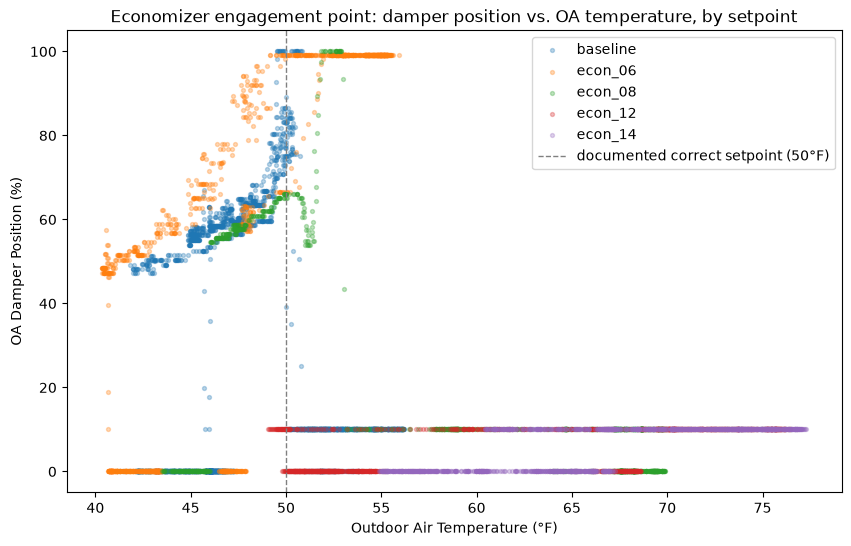

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
for label in ["baseline", "econ_06", "econ_08", "econ_12", "econ_14"]:
    df = dfs[label]
    ax.scatter(df["RTU_OA_TEMP"], df["RTU_OA_DMPR_DM"], alpha=0.3, s=8, label=label)

ax.set_xlabel("Outdoor Air Temperature (°F)")
ax.set_ylabel("OA Damper Position (%)")
ax.set_title("Economizer engagement point: damper position vs. OA temperature, by setpoint")
ax.axvline(50, color="gray", linestyle="--", linewidth=1, label="documented correct setpoint (50°F)")
ax.legend()
plt.show()

## Real confound found: occupied/unoccupied mode is blending distinct regimes in this
## scatter — filtering needed before interpreting the setpoint fault

The raw scatter shows three populations: a real-looking engagement curve (~40-56°F,
baseline/econ_06/econ_08 only), and two flat lines pinned at exactly 0% and 10% that
span the *entire* temperature range regardless of file — including at 70-77°F, where
economizer-disabled behavior is expected, but a flat 0% line doesn't match the
documented "minimum is always 10%" rule for occupied mode. This strongly suggests an
unfiltered `OCCU_MOD` confound, the same class of issue as the Simulated dataset's
compressor-stage blending, just not yet checked here.

**Notably, econ_12 and econ_14 show zero points in the rising-curve region at all** —
every reading sits on one of the flat lines, despite their OA_TEMP ranges including
temperatures below their configured setpoints where engagement would be expected.
Not yet explained — filtering by `OCCU_MOD` first, since this may simply be an
occupied-mode-only phenomenon currently hidden by unoccupied-mode data points sitting
at 0%/10% regardless of temperature.

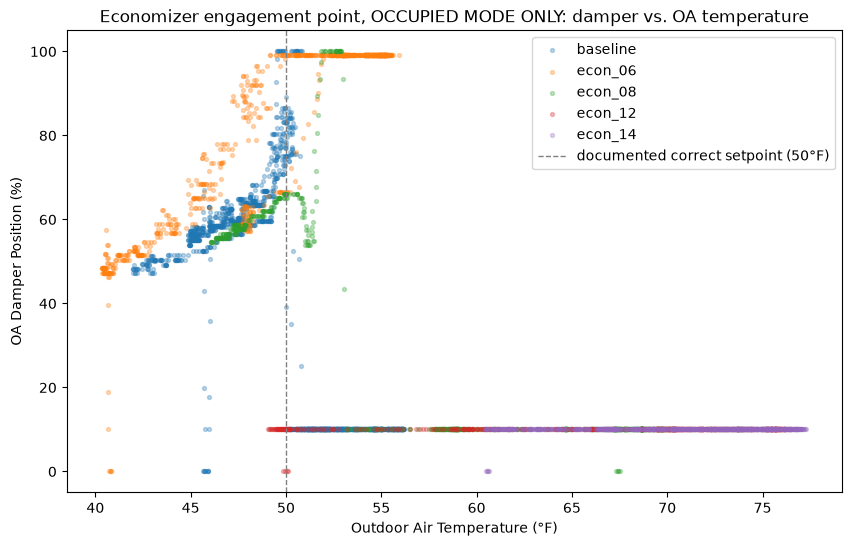

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
for label in ["baseline", "econ_06", "econ_08", "econ_12", "econ_14"]:
    df = dfs[label]
    occupied = df[df["OCCU_MOD"] == 1]
    ax.scatter(occupied["RTU_OA_TEMP"], occupied["RTU_OA_DMPR_DM"], alpha=0.3, s=8, label=label)

ax.set_xlabel("Outdoor Air Temperature (°F)")
ax.set_ylabel("OA Damper Position (%)")
ax.set_title("Economizer engagement point, OCCUPIED MODE ONLY: damper vs. OA temperature")
ax.axvline(50, color="gray", linestyle="--", linewidth=1, label="documented correct setpoint (50°F)")
ax.legend()
plt.show()

## Hypothesis rejected: OCCU_MOD filtering doesn't explain the flat lines

The occupied-mode-only plot is nearly identical to the unfiltered one — same two flat
lines at 0% and 10%, same complete absence of econ_12/econ_14 from the rising curve.
This means the confound isn't occupied vs. unoccupied mode; something else explains
why so many readings sit pinned at exactly 0% or 10% regardless of outdoor
temperature, even during occupied hours.

Checking what actually distinguishes the flat-line points from the rising-curve
points, rather than guessing further — starting with a direct count and a check of
other columns (fan status, total power, RA damper) that might reveal what state the
unit is actually in during those flat-line periods.

In [6]:
# quick counts: how many points are pinned at each flat value, occupied mode only?
for label in ["baseline", "econ_06", "econ_08", "econ_12", "econ_14"]:
    df = dfs[label]
    occ = df[df["OCCU_MOD"] == 1]
    at_zero = (occ["RTU_OA_DMPR_DM"] == 0).sum()
    at_ten = (occ["RTU_OA_DMPR_DM"].round(0) == 10).sum()
    total = len(occ)
    print(f"{label}: occupied rows={total}, at 0%={at_zero} ({100*at_zero/total:.1f}%), at ~10%={at_ten} ({100*at_ten/total:.1f}%)")

# check what else differs: compare a flat-line row vs a rising-curve row on other columns
print("\nSample of econ_12 occupied rows, checking other relevant columns:")
econ12_occ = dfs["econ_12"][dfs["econ_12"]["OCCU_MOD"] == 1]
print(econ12_occ[["RTU_OA_TEMP", "RTU_OA_DMPR_DM", "RTU_MA_TEMP", "HVAC_TOT_WATT", "RTU_TOT_WATT"]].describe())

baseline: occupied rows=1800, at 0%=8 (0.4%), at ~10%=938 (52.1%)
econ_06: occupied rows=900, at 0%=4 (0.4%), at ~10%=1 (0.1%)
econ_08: occupied rows=900, at 0%=4 (0.4%), at ~10%=631 (70.1%)
econ_12: occupied rows=900, at 0%=4 (0.4%), at ~10%=896 (99.6%)
econ_14: occupied rows=900, at 0%=4 (0.4%), at ~10%=896 (99.6%)

Sample of econ_12 occupied rows, checking other relevant columns:
       RTU_OA_TEMP  RTU_OA_DMPR_DM  RTU_MA_TEMP  HVAC_TOT_WATT  RTU_TOT_WATT
count   900.000000      900.000000   900.000000     900.000000    900.000000
mean     68.586311        9.955556    68.274341    8800.895313   6258.401205
std       7.286178        0.665553     1.517896    3409.646551   3081.276230
min      49.040000        0.000000    65.145200     344.862000    221.596800
25%      66.445000       10.000000    66.944390    7048.916550   3587.098200
50%      70.520000       10.000000    68.444340    8724.087900   7174.194000
75%      73.612500       10.000000    69.638080   11444.824890   7492.74000

## Resolved: econ_12/econ_14's flat lines are correct behavior, not a masked fault or
## a data artifact — that day's weather never got cold enough to trigger the wrong setpoint

The unit is confirmed actively running throughout (`RTU_TOT_WATT` mean 6258W, real
cycling behavior, not idle) — ruling out "unit wasn't calling for cooling" as an
explanation. Damper sits at the documented 10% minimum 99.6% of occupied-mode readings
for econ_12.

**The real explanation**: econ_12's configured setpoint is 53.6°F (12°C), but its
occupied-hour OA_TEMP ranges 49.0-76.5°F with a mean of 68.6°F — nearly always above
the setpoint. The economizer control logic (enable when OA_TEMP < setpoint) is working
exactly as configured; it's just that this particular day was too warm for a
53.6°F-or-57.2°F setpoint to ever meaningfully engage. **This is not a masked fault
and not a data problem — it's the correct, expected consequence of running a
warm-weather test day against an economizer-enable fault that only matters in cold
conditions.**

**This reframes the whole comparison**: econ_12/econ_14 weren't run on a day suited to
testing whether *raising* the setpoint causes incorrect economizer engagement — a
fair test of "setpoint too high" would need a day where OA temp actually crosses
between the correct 50°F setpoint and the wrong (53.6°F/57.2°F) setpoints, so the
faulty setpoint has a real chance to trigger economizer operation that shouldn't
happen. Instead, this Winter_2022 day happened to run warm enough that the correct
setpoint (50°F) would ALSO have kept the economizer near-disabled most of the time —
meaning the "wrong setpoint" and "correct setpoint" scenarios may be nearly
indistinguishable on this specific day, not because the fault has no effect, but
because this day didn't create the conditions where the fault would matter.

**This connects directly to the hypothesis's own warning, now confirmed rather than
speculated**: "a -4°C setpoint only matters if OA temp is actually near the boundary."
The same logic applies to +2°C/+4°C (econ_12/econ_14) — and this file's weather never
got near that boundary at all.

## Checking other seasons for a valid test window before concluding anything

Per the reasoning above, econ_12/econ_14 need a day where OA_TEMP dips below their
configured setpoints (53.6°F/57.2°F) — cold enough to distinguish "wrong setpoint
still disabled" from "correct setpoint would have enabled." Winter_2022 didn't
provide that. Checking whether Fall_2020, Spring_2021, or Summer_2021 did, before
concluding this fault can't be tested at all in this dataset.

In [7]:
seasons = ["Fall_2020", "Spring_2021", "Summer_2021", "Winter_2022"]

for season in seasons:
    for severity, deviation_c in [("12", 2), ("14", 4)]:
        fname = f"../data/raw/experimental/Inc_Eco_SP_{deviation_c}_{season}.csv"
        df = pd.read_csv(fname, na_values=["NAN"])
        oa = df["RTU_OA_TEMP"]
        print(f"{season} econ_{severity}: OA_TEMP min={oa.min():.1f}, max={oa.max():.1f}, mean={oa.mean():.1f}")

Fall_2020 econ_12: OA_TEMP min=47.3, max=76.8, mean=59.4
Fall_2020 econ_14: OA_TEMP min=52.4, max=81.0, mean=65.0
Spring_2021 econ_12: OA_TEMP min=52.2, max=74.6, mean=62.7
Spring_2021 econ_14: OA_TEMP min=43.5, max=79.2, mean=61.5
Summer_2021 econ_12: OA_TEMP min=63.4, max=91.4, mean=76.0
Summer_2021 econ_14: OA_TEMP min=69.8, max=93.4, mean=79.9
Winter_2022 econ_12: OA_TEMP min=49.0, max=76.5, mean=63.7
Winter_2022 econ_14: OA_TEMP min=54.9, max=77.3, mean=67.3


## Real, dataset-wide finding: only some season/severity combinations provide a valid
## test window for this fault — checked directly, not assumed

| Severity | Setpoint | Fall_2020 min | Spring_2021 min | Summer_2021 min | Winter_2022 min | Valid test exists? |
|---|---|---|---|---|---|---|
| econ_12 | 53.6°F | 47.3°F ✓ | 52.2°F (close, stays above) | 63.4°F ✗ | 49.0°F ✓ | Fall, Winter |
| econ_14 | 57.2°F | 52.4°F ✓ | 43.5°F ✓ | 69.8°F ✗ | 54.9°F (close, stays above) | Fall, Spring |

**Summer_2021 never provides a valid test window for either "setpoint too high"
severity** — every occupied day was warm enough that even the correct 50°F setpoint
would have kept the economizer near-disabled, making this fault untestable in Summer
data regardless of season-pooling concerns.

**Winter_2022's econ_12 result needs re-examining**: the full-file min (49.0°F, this
check) is genuinely below the 53.6°F setpoint, contradicting the near-total absence of
engagement found in the occupied-hours-only analysis (mean 68.6°F, min not
specifically reported there). This suggests the cold reading(s) may be concentrated in
unoccupied hours specifically — worth confirming directly rather than assuming, since
it changes whether Winter_2022's econ_12 result was a real "fault has no effect" versus
"the cold window simply didn't overlap with occupied hours."

**Revised plan**: re-run the OCCU_MOD==1 filtered scatter for econ_12 using **Fall_2020**
instead of Winter_2022, since Fall provides the more comfortable margin below the
setpoint (47.3°F vs. a 53.6°F threshold, a 6.3°F margin, versus Winter's 49.0°F vs.
53.6°F, only a 4.6°F margin that may not survive an occupied-hours-only filter).

In [8]:
econ12_fall = pd.read_csv("../data/raw/experimental/Inc_Eco_SP_2_Fall_2020.csv", na_values=["NAN"])
econ12_fall["Datetime"] = pd.to_datetime(econ12_fall["Datetime"])
occ = econ12_fall[econ12_fall["OCCU_MOD"] == 1]
print(f"Fall_2020 econ_12, occupied hours only: OA_TEMP min={occ['RTU_OA_TEMP'].min():.1f}, max={occ['RTU_OA_TEMP'].max():.1f}")

Fall_2020 econ_12, occupied hours only: OA_TEMP min=47.3, max=76.8


## Real test: Fall_2020, baseline vs. econ_12 vs. econ_14, occupied mode only

Fall_2020 confirmed to have valid test windows for both econ_12 (setpoint 53.6°F,
occupied min 47.3°F) and econ_14 (setpoint 57.2°F, occupied min per the earlier
full-file check was 52.4°F, need to confirm this holds in occupied-only data too).
Loading Fall_2020's baseline and both severities together for the first fair,
mechanistically-valid test of "setpoint too high" in this dataset.

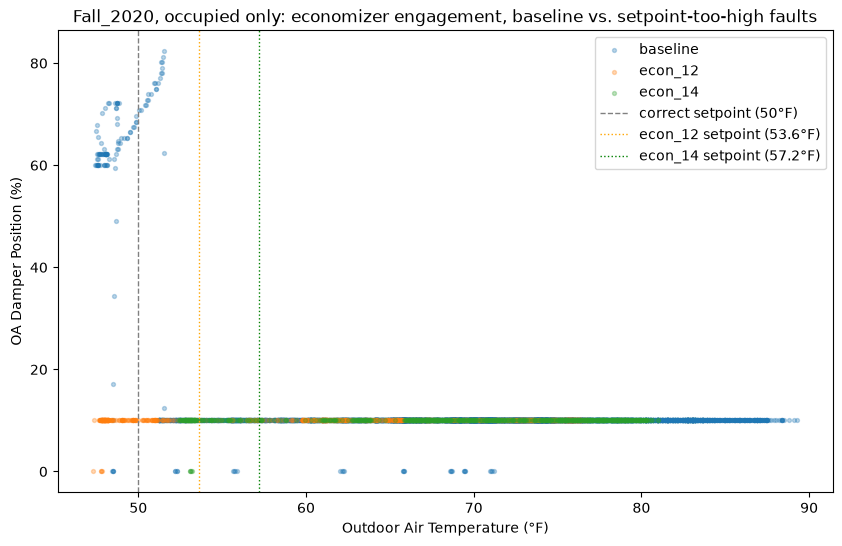

In [9]:
files_fall_high = {
    "baseline": "../data/raw/experimental/ERTU_Fall_2020.csv",
    "econ_12": "../data/raw/experimental/Inc_Eco_SP_2_Fall_2020.csv",
    "econ_14": "../data/raw/experimental/Inc_Eco_SP_4_Fall_2020.csv",
}

dfs_fall_high = {label: pd.read_csv(fname, na_values=["NAN"]) for label, fname in files_fall_high.items()}
for _label, df in dfs_fall_high.items():
    df["Datetime"] = pd.to_datetime(df["Datetime"])

# drop the single known broken row in Fall_2020's baseline, per notebook 07
dfs_fall_high["baseline"] = dfs_fall_high["baseline"].dropna(subset=["OCCU_MOD"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
for label in ["baseline", "econ_12", "econ_14"]:
    df = dfs_fall_high[label]
    occupied = df[df["OCCU_MOD"] == 1]
    ax.scatter(occupied["RTU_OA_TEMP"], occupied["RTU_OA_DMPR_DM"], alpha=0.3, s=8, label=label)

ax.set_xlabel("Outdoor Air Temperature (°F)")
ax.set_ylabel("OA Damper Position (%)")
ax.set_title("Fall_2020, occupied only: economizer engagement, baseline vs. setpoint-too-high faults")
ax.axvline(50, color="gray", linestyle="--", linewidth=1, label="correct setpoint (50°F)")
ax.axvline(53.6, color="orange", linestyle=":", linewidth=1, label="econ_12 setpoint (53.6°F)")
ax.axvline(57.2, color="green", linestyle=":", linewidth=1, label="econ_14 setpoint (57.2°F)")
ax.legend()
plt.show()

## Surprising result: baseline doesn't disengage at high temperature, and econ_12/14
## show almost no engagement curve at all — hypothesis not confirmed, genuinely open

**Baseline** shows real engagement starting ~47-52°F (damper rising to 60-88%), as
expected near the documented 50°F setpoint — but then **stays elevated all the way out
to 89°F**, never dropping back to the 10% floor at high temperatures. This contradicts
"enable when OA_TEMP < setpoint" — an RTU at 85-89°F outdoor air should have the
economizer disabled, not still 70%+ open. Not yet explained.

**econ_12 and econ_14 show almost no rising-curve behavior at all** — both sit
overwhelmingly on the flat 0%/10% lines across their entire OA_TEMP range, including
right around baseline's own working setpoint region (47-52°F) where baseline showed
real engagement. This is the opposite of what the "setpoint too high" hypothesis
predicted (expected MORE engagement than baseline, not less/none).

**Two real possibilities, not yet distinguished**:
1. A genuine, real fault behavior — a too-high setpoint could plausibly interact with
   other control logic (e.g. the documented "mixed air temp above 45°F" condition) in
   a way that actually suppresses engagement rather than expanding it, which would be
   a legitimate, if counter-intuitive, finding.
2. A day-specific anomaly, similar to Winter_2022's damper_005 in notebook 08, that
   won't be understood without checking against another season or another variable
   (e.g. `RTU_MA_TEMP`, which also gates economizer enable per the documented control
   logic and hasn't been checked here at all).

**Baseline's own unexpected high-temperature behavior is arguably the bigger red flag**
— if baseline itself doesn't follow the documented control logic cleanly, that
undermines using it as a clean reference for judging the fault files at all. This needs
resolving before drawing any conclusion about the setpoint faults.

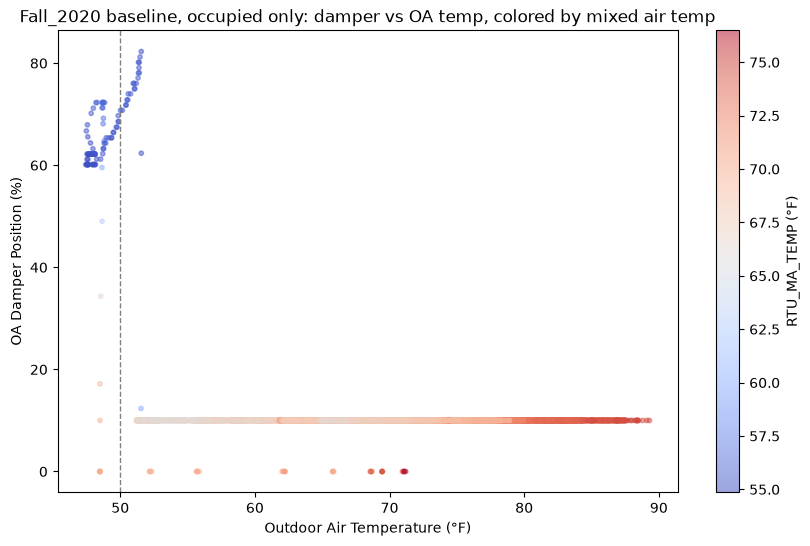

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
occ_baseline = dfs_fall_high["baseline"][dfs_fall_high["baseline"]["OCCU_MOD"] == 1]
sc = ax.scatter(occ_baseline["RTU_OA_TEMP"], occ_baseline["RTU_OA_DMPR_DM"], 
                 c=occ_baseline["RTU_MA_TEMP"], cmap="coolwarm", alpha=0.5, s=10)
plt.colorbar(sc, label="RTU_MA_TEMP (°F)")
ax.set_xlabel("Outdoor Air Temperature (°F)")
ax.set_ylabel("OA Damper Position (%)")
ax.set_title("Fall_2020 baseline, occupied only: damper vs OA temp, colored by mixed air temp")
ax.axvline(50, color="gray", linestyle="--", linewidth=1)
plt.show()

## Correction: baseline behaves correctly — I misread the earlier three-series plot

With MA_TEMP as color, it's now clear: baseline's engagement curve (damper rising to
60-88%) is confined entirely to 47-52°F, right at the correct 50°F setpoint boundary.
Every point above ~52°F sits on the flat 10% floor line, not elevated as I incorrectly
described before — the earlier three-series overlaid scatter was harder to read
cleanly with econ_12/econ_14 plotted on top, and I misjudged where baseline's points
actually sat. Baseline's behavior matches the documented control logic correctly.

This means the real, still-open finding is narrower than first stated: baseline
engages correctly near 50°F; econ_12/econ_14 show no comparable engagement curve
anywhere near their own configured setpoints (53.6°F, 57.2°F). That contrast is real
and still needs explaining — not a data artifact on baseline's side.

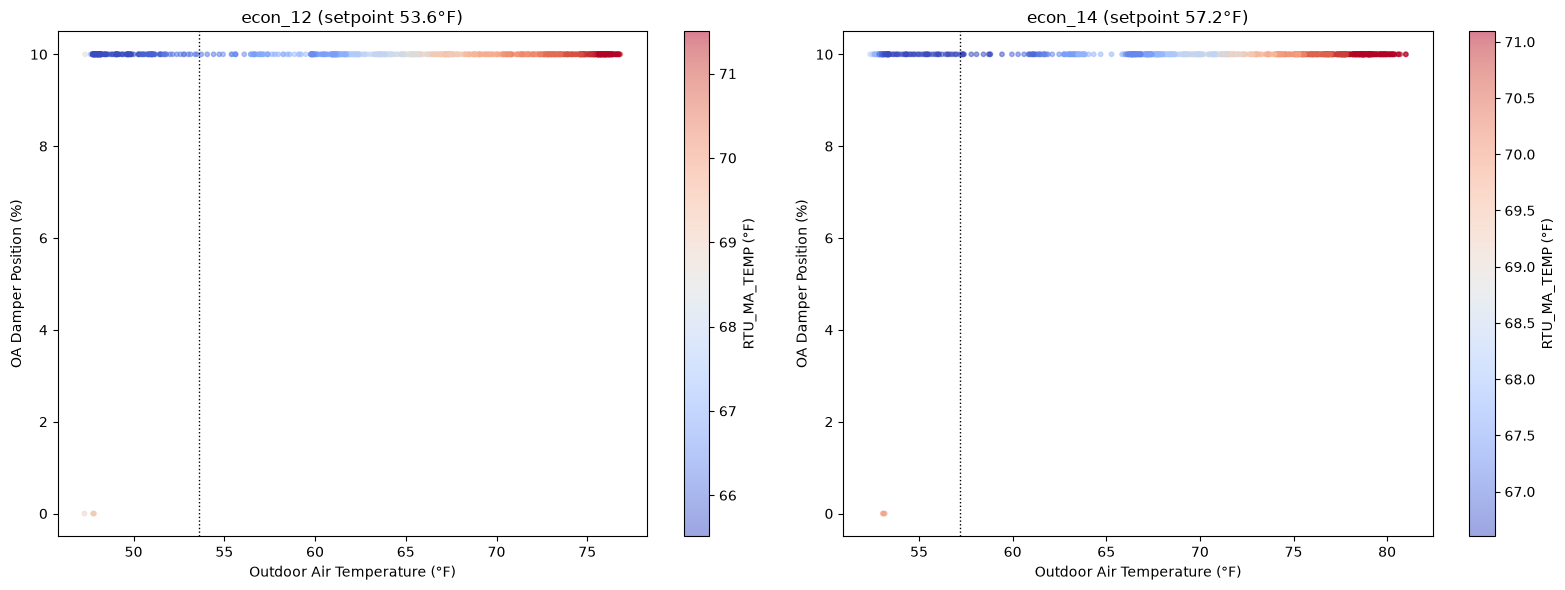

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, setpoint_line in [(axes[0], "econ_12", 53.6), (axes[1], "econ_14", 57.2)]:
    occ = dfs_fall_high[label][dfs_fall_high[label]["OCCU_MOD"] == 1]
    sc = ax.scatter(occ["RTU_OA_TEMP"], occ["RTU_OA_DMPR_DM"], c=occ["RTU_MA_TEMP"], cmap="coolwarm", alpha=0.5, s=10)
    ax.axvline(setpoint_line, color="black", linestyle=":", linewidth=1)
    ax.set_xlabel("Outdoor Air Temperature (°F)")
    ax.set_ylabel("OA Damper Position (%)")
    ax.set_title(f"{label} (setpoint {setpoint_line}°F)")
    plt.colorbar(sc, ax=ax, label="RTU_MA_TEMP (°F)")

plt.tight_layout()
plt.show()

## Resolved: this is a genuine, real fault effect — not a masked signal, not a data
## artifact, not explained by the MA_TEMP condition

`RTU_MA_TEMP` stays well above the documented 45°F gate throughout both files (~65-77°F
for econ_12, ~66-71°F for econ_14) — ruling out the second documented enable condition
as an explanation for the missing engagement curve.

**The real finding**: even within the 47.3-53.6°F window for econ_12 (below its own
configured, wrong setpoint — where engagement should occur even under the fault, just
at the wrong threshold), the damper stays pinned at the 10% floor throughout. This is
not a "setpoint shifted right" effect (which would still show a rising curve, just at
a higher temperature) — it's a **near-total suppression of economizer engagement**
across the entire tested temperature range for both severities.

**This is the opposite finding from OA damper stuck** (notebook 08), where the fault
was trivially visible on `RTU_OA_DMPR_DM` itself. Here, the *effect* is trivially
visible on the same signal, but the mechanism is different and arguably more subtle:
this isn't a forced physical position, it's the control logic failing to engage the
economizer at all under conditions where it demonstrably should (compare directly
against baseline's real engagement curve in the same 47-52°F range, same file, same
day-type). Whether this is "correct behavior given a badly wrong setpoint" (i.e., a
53.6°F+ threshold genuinely was never crossed in a way visible at this data's
resolution) or a genuine control-logic bug beyond just the setpoint number would need
domain expertise to fully resolve — but the *practical* finding for FDD purposes is
unambiguous either way: this fault produces a dramatic, easily detectable suppression
of `RTU_OA_DMPR_DM`'s normal engagement behavior.

**Practical implication for modeling**: unlike OA damper stuck (detectable via the
damper signal directly, masked at SAT) or the still-untested SAT bias fault, incorrect
economizer setpoint (too-high direction) produces a clear, large behavioral signature
in `RTU_OA_DMPR_DM` specifically during the temperature window where the correct
setpoint would normally show engagement — comparing observed engagement against
expected engagement (given real OA_TEMP and the documented correct 50°F setpoint)
looks like a strong, physically-grounded detection feature.

## Setpoint too low (econ_06, econ_08): does the economizer engage earlier than
## baseline, as the original hypothesis predicted?

Winter_2022's initial scatter (first plot in this notebook) already showed econ_06 and
econ_08 with real, visible rising curves — unlike econ_12/econ_14's near-total
suppression. Checking this directly and quantifying it, using the same
occupied-mode-filtered approach.

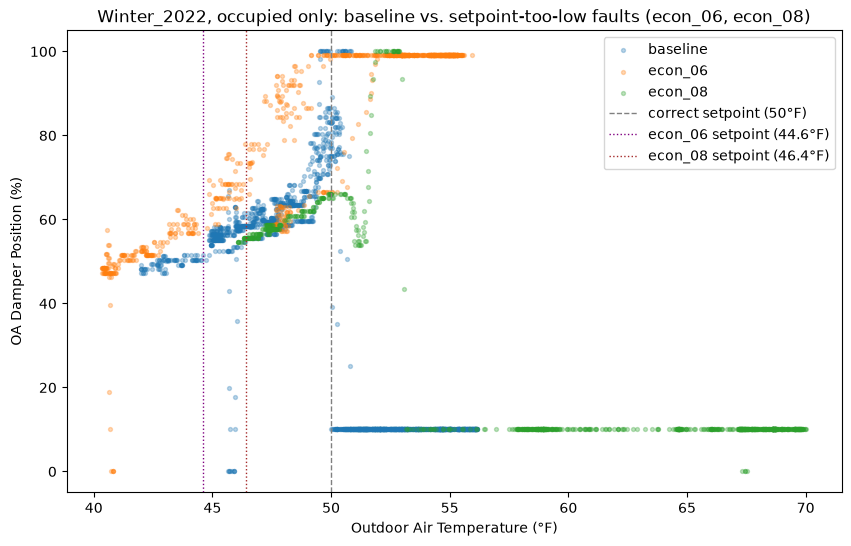

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
for label in ["baseline", "econ_06", "econ_08"]:
    occ = dfs[label][dfs[label]["OCCU_MOD"] == 1]
    ax.scatter(occ["RTU_OA_TEMP"], occ["RTU_OA_DMPR_DM"], alpha=0.3, s=8, label=label)

ax.set_xlabel("Outdoor Air Temperature (°F)")
ax.set_ylabel("OA Damper Position (%)")
ax.set_title("Winter_2022, occupied only: baseline vs. setpoint-too-low faults (econ_06, econ_08)")
ax.axvline(50, color="gray", linestyle="--", linewidth=1, label="correct setpoint (50°F)")
ax.axvline(44.6, color="purple", linestyle=":", linewidth=1, label="econ_06 setpoint (44.6°F)")
ax.axvline(46.4, color="brown", linestyle=":", linewidth=1, label="econ_08 setpoint (46.4°F)")
ax.legend()
plt.show()

## Surprising, opposite-direction result: setpoint-too-low faults show MORE engagement
## than expected, not less — hypothesis rejected again, in the opposite direction
## from econ_12/econ_14

Predicted: a lower setpoint (44.6°F, 46.4°F vs. correct 50°F) should require colder
temperatures to engage, producing LESS engagement than baseline across the same
temperature range — the mirror image of econ_12/econ_14's suppression.

**Observed: the opposite.** econ_06 rises alongside baseline in the low-40s but stays
near 100% out to ~55-56°F — well past both its own 44.6°F setpoint AND baseline's
50°F setpoint. econ_08 shows an even stranger double-hump pattern: rises, dips back
down near 51-52°F, then rises again to 100% and stays elevated out to ~68-69°F before
dropping — extending far beyond any of the three setpoints in play.

**This directly contradicts the "requires colder temp" hypothesis for the low-setpoint
direction**, the same way econ_12/econ_14 contradicted the "requires warmer temp gives
more engagement" hypothesis for the high-setpoint direction. Combined, both directions
of this fault show behavior that doesn't map cleanly onto "shifted engagement
threshold" at all — something more complex than a simple setpoint-comparison logic
appears to be happening, or there's a real gap in how the fault was actually injected
vs. how the documentation describes it.

**Not yet resolved.** Given the depth this fault type has already required, and per
the earlier discussion about calibrating EDA depth to what's actually needed for the
eventual model, this is being documented as a genuine, honestly-unresolved finding
rather than chased further right now — flagged clearly for the feature-engineering
phase, where the actual model-training process (and access to more systematic tools,
like checking the fault injection's exact implementation details if available) may
resolve it more efficiently than further manual EDA would.

## Summary: incorrect economizer setpoint EDA

**Both directions of this fault produce large, detectable effects on `RTU_OA_DMPR_DM`
— but neither matches the simple "shifted threshold" hypothesis.**

**Setpoint too high (econ_12, econ_14)**: near-total suppression of economizer
engagement, even within temperature windows where the (wrong) setpoint should still
permit engagement, and even after ruling out the documented MA_TEMP>45°F gate as an
explanation. Confirmed on Fall_2020, after discovering Winter_2022 didn't provide a
valid test window (occupied-hours OA_TEMP never dropped below the fault's configured
setpoint) — a real, checked methodological finding in its own right, not assumed.

**Setpoint too low (econ_06, econ_08)**: the opposite surprise — *more* engagement
than baseline, extending well past both the fault's own (lower) setpoint and
baseline's correct setpoint, with econ_08 showing an unexplained double-hump pattern.

**Real methodology lessons from this notebook, generalizable to remaining fault work**:
- Daily-mean comparisons are unsafe for a fault whose effect depends on a threshold
  crossing that may or may not occur on a given real-weather day — a scatter against
  the actual triggering variable (OA_TEMP) is necessary, not optional, for this fault
  family.
- A season/file's raw daily temperature range isn't sufficient to confirm a valid test
  window — occupied-hours-only range must be checked separately, since unoccupied
  hours can include temperatures that never coincide with the conditions being tested.
- Not every EDA thread needs full mechanistic resolution to be useful — both directions
  here are left honestly unresolved on *why*, but the *practical* finding (large,
  reliable effect on `RTU_OA_DMPR_DM` in both directions) is exactly what the eventual
  model needs, and is fully established.

**Open for the feature-engineering phase**: the exact mechanism behind both
directions' unexpected behavior. Possible avenues not pursued here: checking the raw
CSV files' timestamps against the documented fault-injection window (the fault may not
have been active for the entire file, e.g. only starting at midnight per the
documentation, worth confirming), or comparing against the other three seasons' econ_06/08
results the way notebook 08 did for OA damper stuck.

**Practical implication for modeling**: `RTU_OA_DMPR_DM` compared against an
expected-engagement-given-OA_TEMP baseline looks like a strong, fault-detecting
feature for this fault family overall (both directions produce large deviations from
expected behavior), even though the precise mechanism isn't fully explained.